# **Expected Loss**

In [1]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.4f}'.format)

## **What This Notebook Does**

This notebook assembles the three component models into a single **Expected Loss** framework:

$$\text{EL} = \text{PD} \times \text{LGD} \times \text{EAD}$$

where:
- **PD** is the probability that a borrower defaults, predicted by `pd_model.pkl`
- **LGD** is the fraction of the exposure lost given default (0–1), predicted by `lgd_model.pkl`
- **EAD** is the dollar amount at risk at the moment of default, derived from `ead_ratio × funded_amnt` using `ead_model.pkl`

A key nuance: LGD and EAD were **trained on defaulted loans only** (that was the methodologically correct choice for fitting those models). Here, we apply them to the **full portfolio** to estimate the *expected* loss-given-default and *expected* exposure-at-default *conditional on default occurring*. This is standard in credit risk — you model each component on the population where it is defined, then multiply.

From EL, the notebook produces:

1. **Portfolio-level EL summary** — total and per-loan EL across the full book.
2. **Segmentation** — EL decomposed by grade, term, purpose, and vintage year.
3. **Cutoff simulation** — what happens to approval rate, portfolio EL, and average PD if we tighten the PD decision threshold.
4. **EL concentration analysis** — what share of total EL is concentrated in the riskiest borrowers.

## **Load Trained Models**

In [2]:
from credit_risk_pipeline import (
    ColumnNameCleaner, EmpLengthTransformer, CategoricalCleaner, 
    TermTransformer, LoanStatusCleaner, GradeTransformer, 
    IssueDateTransformer, Winsorizer, WoEEncoder, 
    FeatureDropper, LoanFeatureEngineer, PDPreprocessor, PDModel
)

In [3]:
pd_preprocessor  = joblib.load('pd_preprocessor.pkl')
pd_model         = joblib.load('pd_model.pkl')

lgd_preprocessor = joblib.load('lgd_preprocessor.pkl')
lgd_model        = joblib.load('lgd_model.pkl')

ead_preprocessor = joblib.load('ead_preprocessor.pkl')
ead_model        = joblib.load('ead_model.pkl')

print('All models loaded successfully.')

All models loaded successfully.


## **Custom Transformers**

Same structural transformers as in the three model notebooks. Needed to preprocess the raw data before passing it to the PKL preprocessors.

In [4]:
from sklearn.base import BaseEstimator, TransformerMixin


class ColumnNameCleaner(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None): return self
    def transform(self, X):
        X = X.copy()
        X.columns = X.columns.str.strip().str.lower().str.replace(' ', '_')
        return X


class LoanStatusCleaner(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.target_map = {'fully_paid': 0, 'charged_off': 1}
    def fit(self, X, y=None): return self
    def transform(self, X):
        X_copy = X.copy()
        X_copy = X_copy[X_copy['loan_status'].isin(self.target_map.keys())]
        X_copy['is_default'] = X_copy['loan_status'].map(self.target_map)
        return X_copy


class CategoricalCleaner(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None): return self
    def transform(self, X):
        X = X.copy()
        for col in X.select_dtypes(include=['object']).columns:
            X[col] = (
                X[col]
                .str.lower()
                .str.replace(' ', '_', regex=False)
                .str.replace('-', '_', regex=False)
                .str.lstrip('_')
            )
        return X


class GradeTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        grades = ['a', 'b', 'c', 'd', 'e', 'f', 'g']
        self.mapping = {
            f"{g}{i}": (count - 1) * 5 + i
            for count, g in enumerate(grades, 1)
            for i in range(1, 6)
        }
    def fit(self, X, y=None): return self
    def transform(self, X):
        X = X.copy()
        if 'sub_grade' in X.columns:
            X['sub_grade_num'] = X['sub_grade'].str.lower().map(self.mapping).fillna(0)
            X = X.drop(columns=[c for c in ['grade', 'sub_grade'] if c in X.columns])
        return X


class IssueDateTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, column='issue_d'):
        self.column = column
    def fit(self, X, y=None): return self
    def transform(self, X):
        X = X.copy()
        X[self.column] = pd.to_datetime(X[self.column], format='%b_%Y', errors='coerce')
        X['issue_d_year']    = X[self.column].dt.year
        X['issue_d_quarter'] = X[self.column].dt.to_period('Q')
        return X


class EmpLengthTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.fill_value = None
    def fit(self, X, y=None):
        temp = pd.Series(X).replace('< 1 year', '0').str.extract('(\d+)').astype(float)
        self.fill_value = temp.mode()[0]
        return self
    def transform(self, X):
        s = pd.Series(X).replace('< 1 year', '0')
        s = s.str.extract('(\d+)', expand=False).astype(float).fillna(self.fill_value)
        return s.values.reshape(-1, 1)


class LoanFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self._mean_rate_by_grade = None
    def fit(self, X, y=None):
        if 'sub_grade_num' in X.columns and 'int_rate' in X.columns:
            self._mean_rate_by_grade = X.groupby('sub_grade_num')['int_rate'].mean()
        return self
    def transform(self, X):
        X = X.copy()
        X['loan_to_income']  = X['funded_amnt'] / (X['annual_inc'] + 1)
        X['payment_burden']  = (X['installment'] * 12) / (X['annual_inc'] + 1)
        X['log_annual_inc']  = np.log1p(X['annual_inc'])
        if 'purpose' in X.columns:
            X['is_risky_purpose'] = np.where(X['purpose'] == 'small_business', 1, 0)
        if 'dti' in X.columns and 'term' in X.columns:
            X['dti_x_term'] = X['dti'] * X['term']
        if self._mean_rate_by_grade is not None:
            expected_rate = X['sub_grade_num'].map(self._mean_rate_by_grade)
            X['int_rate_residual'] = X['int_rate'] - expected_rate
        if 'log_annual_inc' in X.columns and 'emp_length' in X.columns:
            X['inc_stability'] = X['log_annual_inc'] * X['emp_length']
        return X


print('Transformers defined.')

Transformers defined.


## **Load & Preprocess the Full Portfolio**

We load the same columns used across the three model notebooks, plus `grade` (for segmentation analysis) and the outcome columns. The preprocessing here mirrors what was done in training, same transformers, same order, but we **do not** fit anything. All fitted transformers (Winsorizer bounds, WoE weights, OHE categories) are already embedded in the PKL preprocessors.

In [5]:
df_raw = pd.read_parquet('accepted.parquet', columns=[
    'loan_status',
    'funded_amnt',
    'annual_inc',
    'dti',
    'grade',
    'sub_grade',
    'int_rate',
    'emp_length',
    'home_ownership',
    'purpose',
    'term',
    'issue_d',
    'installment',
])

print(f'Raw dataset: {len(df_raw):,} rows')

Raw dataset: 2,260,701 rows


In [6]:
# Structural preprocessing (transform only, no fitting)
df = df_raw.copy()
df = ColumnNameCleaner().transform(df)
df = CategoricalCleaner().transform(df)
df = LoanStatusCleaner().transform(df)   # keeps only fully_paid + charged_off

_emp = EmpLengthTransformer()
_emp.fit(df['emp_length'])
df['emp_length'] = _emp.transform(df['emp_length'])

df['term'] = df['term'].str.extract('(\d+)', expand=False).astype(float)
df = GradeTransformer().transform(df)
df = IssueDateTransformer().transform(df)

# Save grade label before it gets dropped by the PKL preprocessors
# (sub_grade_num is ordinal but we want the letter grade for segmentation)
df['grade_label'] = pd.Categorical(
    df['sub_grade_num'].apply(
        lambda x: 'ABCDEFG'[int((x - 1) // 5)] if pd.notna(x) and x > 0 else 'Unknown'
    ),
    categories=list('ABCDEFG'), ordered=True
)

fe = LoanFeatureEngineer()
fe.fit(df)    # fits mean_rate_by_grade on full portfolio
df = fe.transform(df)

print(f'Processed portfolio: {len(df):,} rows')
print(f'Default rate: {df["is_default"].mean():.2%}')

Processed portfolio: 1,345,310 rows
Default rate: 19.96%


## **Run Inference, PD, LGD, EAD**

Each PKL preprocessor was fitted on its own training set (different populations and fitted parameters). Here we apply each one independently to the full portfolio, the sklearn `ColumnTransformer.transform()` call uses the saved fit state, so no re-fitting occurs.

In [7]:
# Columns that go through each preprocessor
# These must match exactly what was used during training
NUMERIC_BASE    = ['funded_amnt', 'annual_inc', 'dti', 'int_rate',
                    'emp_length', 'term', 'sub_grade_num']
ENGINEERED_NUM  = ['loan_to_income', 'payment_burden', 'log_annual_inc',
                    'dti_x_term', 'int_rate_residual', 'inc_stability']
CATEGORICALS    = ['home_ownership', 'purpose']
FEATURES        = NUMERIC_BASE + ENGINEERED_NUM + CATEGORICALS

X_portfolio = df[FEATURES].copy()

# --- PD ---
X_pd  = pd_preprocessor.transform(X_portfolio)
df['pd_score'] = pd_model.predict_proba(X_pd)

# --- LGD ---
X_lgd = lgd_preprocessor.transform(X_portfolio)
df['lgd_hat'] = lgd_model.predict(X_lgd).clip(0, 1)

# --- EAD ---
X_ead = ead_preprocessor.transform(X_portfolio)
df['ead_ratio_hat'] = ead_model.predict(X_ead).clip(0, 1)
df['ead_hat']       = df['ead_ratio_hat'] * df['funded_amnt']

# --- EL ---
df['el']       = df['pd_score'] * df['lgd_hat'] * df['ead_hat']
df['el_ratio'] = df['pd_score'] * df['lgd_hat'] * df['ead_ratio_hat']  # as fraction of funded_amnt

print('Inference complete.')
df[['pd_score', 'lgd_hat', 'ead_ratio_hat', 'ead_hat', 'el', 'el_ratio']].describe().round(4)

Inference complete.


,pd_score,lgd_hat,ead_ratio_hat,ead_hat,el,el_ratio
count,"1,345,310.0000","1,345,310.0000","1,345,310.0000","1,345,310.0000","1,345,310.0000","1,345,310.0000"
mean,0.4474,0.9249,0.6050,"8,906.3734","3,976.5027",0.2595
std,0.1822,0.0107,0.0711,"5,838.6038","3,612.0226",0.1305
min,0.0347,0.8856,0.5141,285.3197,17.6014,0.0176
25%,0.3138,0.9181,0.5482,"4,371.7276","1,344.7742",0.1614
50%,0.4473,0.9264,0.5840,"7,564.5671","2,680.5064",0.2444
75%,0.5760,0.9328,0.6522,"12,172.6096","5,600.6894",0.3379
max,0.9297,0.9489,0.8339,"33,357.0743","27,585.9572",0.7072


A quick sanity check on the component distributions:
- `pd_score`: should roughly match the observed default rate (~20%). The mean PD across the full portfolio is the model's implicit estimate of portfolio default risk.
- `lgd_hat`: for unsecured consumer loans, expect values concentrated near 0.8–1.0 (high loss severity is typical).
- `ead_ratio_hat`: expect values concentrated toward 1.0 (most defaults happen early, while principal is still mostly outstanding).
- `el_ratio`: typical for Lending Club would be ~10–20% of funded amount for riskier grades, lower for A/B.

## **Portfolio-Level EL Summary**

In [8]:
total_funded = df['funded_amnt'].sum()
total_el     = df['el'].sum()
n_loans      = len(df)

print(f'Number of loans          : {n_loans:>12,}')
print(f'Total funded amount      : ${total_funded:>15,.0f}')
print(f'Total expected loss (EL) : ${total_el:>15,.0f}')
print(f'Portfolio EL ratio       : {total_el/total_funded:>12.2%}')
print(f'Mean EL per loan         : ${df["el"].mean():>15,.2f}')
print(f'Mean EL ratio per loan   : {df["el_ratio"].mean():>12.2%}')
print()
print('--- Component means ---')
print(f'Mean PD score            : {df["pd_score"].mean():>12.2%}')
print(f'Mean LGD (predicted)     : {df["lgd_hat"].mean():>12.2%}')
print(f'Mean EAD ratio (pred.)   : {df["ead_ratio_hat"].mean():>12.2%}')
print()
print('--- Actual portfolio outcomes (observed default rate as reference) ---')
print(f'Observed default rate    : {df["is_default"].mean():>12.2%}')

Number of loans          :    1,345,310
Total funded amount      : $ 19,388,011,250
Total expected loss (EL) : $  5,349,628,865
Portfolio EL ratio       :       27.59%
Mean EL per loan         : $       3,976.50
Mean EL ratio per loan   :       25.95%

--- Component means ---
Mean PD score            :       44.74%
Mean LGD (predicted)     :       92.49%
Mean EAD ratio (pred.)   :       60.50%

--- Actual portfolio outcomes (observed default rate as reference) ---
Observed default rate    :       19.96%


## **EL Segmentation**

### **By Grade**

EL should increase monotonically from A to G — both because PD rises with grade risk and because riskier borrowers tend to default earlier (higher EAD ratio) and recover less (higher LGD).

In [9]:
grade_summary = (
    df.groupby('grade_label', observed=False)
    .agg(
        n_loans      = ('funded_amnt', 'count'),
        total_funded = ('funded_amnt', 'sum'),
        mean_pd      = ('pd_score',    'mean'),
        mean_lgd     = ('lgd_hat',     'mean'),
        mean_ead_r   = ('ead_ratio_hat','mean'),
        total_el     = ('el',          'sum'),
        mean_el_ratio= ('el_ratio',    'mean'),
        obs_default  = ('is_default',  'mean'),
    )
    .reset_index()
)
grade_summary['el_pct_of_book'] = grade_summary['total_el'] / grade_summary['total_el'].sum()

display(grade_summary.round(4))

,grade_label,n_loans,total_funded,mean_pd,mean_lgd,mean_ead_r,total_el,mean_el_ratio,obs_default,el_pct_of_book
0,A,235090,"3,263,667,075.0000",0.1948,0.9333,0.5350,"307,537,585.4697",0.0977,0.0604,0.0575
1,B,392741,"5,195,770,225.0000",0.3689,0.9307,0.5682,"1,045,969,315.1430",0.1968,0.1339,0.1955
2,C,381686,"5,413,618,200.0000",0.5101,0.9234,0.6140,"1,634,202,050.1451",0.2916,0.2244,0.3055
3,D,200953,"3,067,885,950.0000",0.5963,0.9178,0.6565,"1,152,046,998.2764",0.3620,0.3038,0.2154
4,E,93650,"1,648,140,600.0000",0.6943,0.9098,0.7157,"773,089,030.6553",0.4552,0.3848,0.1445
5,F,32058,"611,052,075.0000",0.7614,0.9035,0.7626,"329,293,919.1343",0.5267,0.4520,0.0616
6,G,9132,"187,877,125.0000",0.7931,0.9024,0.7930,"107,489,965.8790",0.5690,0.4993,0.0201


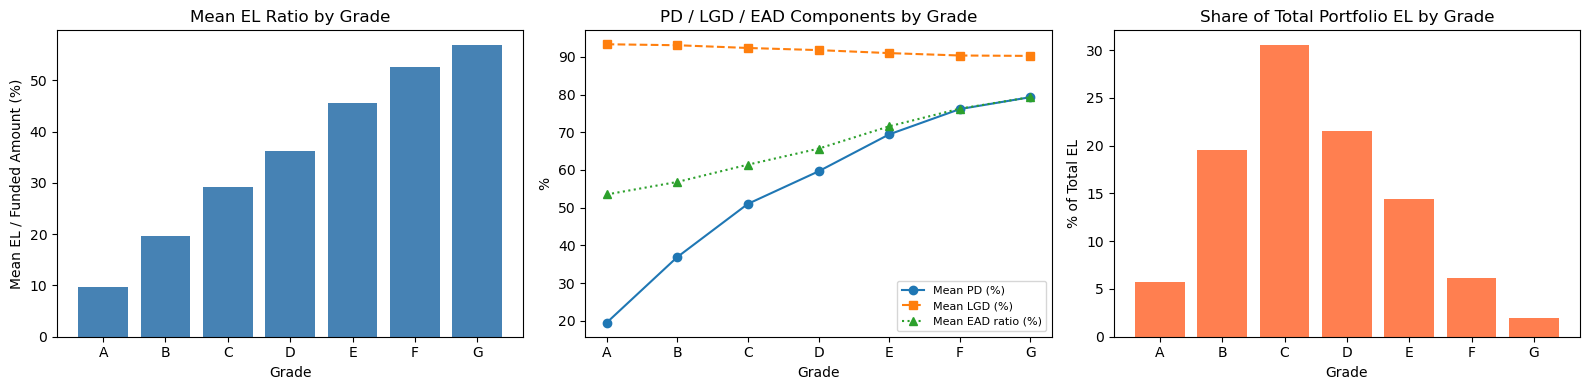

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

grades = grade_summary['grade_label'].astype(str)

# Mean EL ratio by grade
axes[0].bar(grades, grade_summary['mean_el_ratio'] * 100, color='steelblue')
axes[0].set_title('Mean EL Ratio by Grade')
axes[0].set_xlabel('Grade')
axes[0].set_ylabel('Mean EL / Funded Amount (%)')

# PD, LGD, EAD ratio stacked context
axes[1].plot(grades, grade_summary['mean_pd'] * 100,    'o-', label='Mean PD (%)')
axes[1].plot(grades, grade_summary['mean_lgd'] * 100,   's--', label='Mean LGD (%)')
axes[1].plot(grades, grade_summary['mean_ead_r'] * 100, '^:', label='Mean EAD ratio (%)')
axes[1].set_title('PD / LGD / EAD Components by Grade')
axes[1].set_xlabel('Grade')
axes[1].set_ylabel('%')
axes[1].legend(fontsize=8)

# EL concentration by grade
axes[2].bar(grades, grade_summary['el_pct_of_book'] * 100, color='coral')
axes[2].set_title('Share of Total Portfolio EL by Grade')
axes[2].set_xlabel('Grade')
axes[2].set_ylabel('% of Total EL')

plt.tight_layout()
plt.show()

### **By Loan Term**

In [11]:
term_summary = (
    df.groupby('term')
    .agg(
        n_loans       = ('funded_amnt', 'count'),
        mean_pd       = ('pd_score',    'mean'),
        mean_lgd      = ('lgd_hat',     'mean'),
        mean_ead_r    = ('ead_ratio_hat','mean'),
        mean_el_ratio = ('el_ratio',    'mean'),
        obs_default   = ('is_default',  'mean'),
    )
    .reset_index()
)
display(term_summary.round(4))

,term,n_loans,mean_pd,mean_lgd,mean_ead_r,mean_el_ratio,obs_default
0,36.0000,1020743,0.3877,0.9283,0.5717,0.2098,0.1599
1,60.0000,324567,0.6352,0.9139,0.7096,0.4157,0.3245


### **By Purpose**

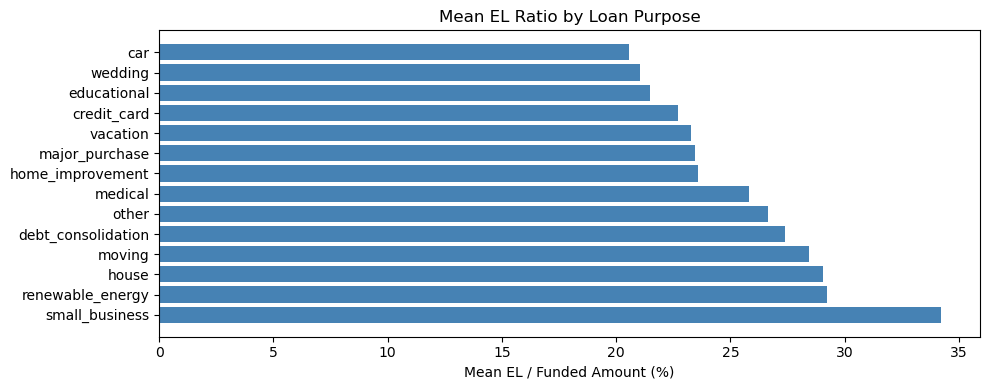

,purpose,n_loans,mean_pd,mean_el_ratio,obs_default
0,small_business,15416,0.5762,0.3421,0.2971
1,renewable_energy,933,0.5036,0.2922,0.2369
2,house,7253,0.4859,0.2905,0.2188
3,moving,9480,0.4914,0.2842,0.2335
4,debt_consolidation,780321,0.4679,0.2739,0.2115
5,other,77875,0.4580,0.2663,0.2104
6,medical,15554,0.4498,0.2582,0.2178
7,home_improvement,87504,0.4072,0.2358,0.1772
8,major_purchase,29425,0.4060,0.2344,0.1860
9,vacation,9065,0.4152,0.2328,0.1917


In [12]:
purpose_summary = (
    df.groupby('purpose')
    .agg(
        n_loans       = ('funded_amnt', 'count'),
        mean_pd       = ('pd_score',    'mean'),
        mean_el_ratio = ('el_ratio',    'mean'),
        obs_default   = ('is_default',  'mean'),
    )
    .sort_values('mean_el_ratio', ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(purpose_summary['purpose'], purpose_summary['mean_el_ratio'] * 100, color='steelblue')
ax.set_xlabel('Mean EL / Funded Amount (%)')
ax.set_title('Mean EL Ratio by Loan Purpose')
plt.tight_layout()
plt.show()

display(purpose_summary.round(4))

### **By Vintage Year**

Vintage analysis shows how EL evolves across origination cohorts. Rising EL ratios in later vintages can indicate loosening credit standards, a more adverse macro environment, or both.

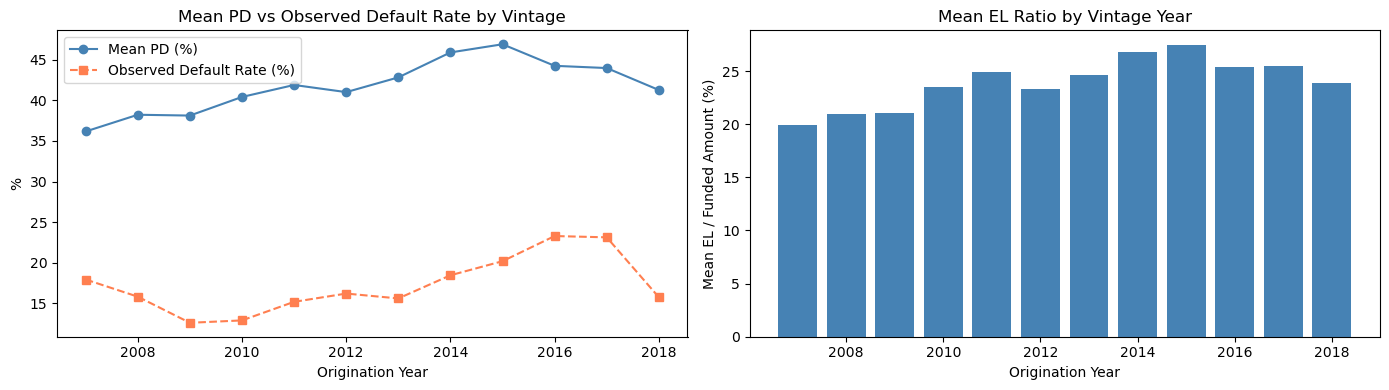

,issue_d_year,n_loans,mean_pd,mean_lgd,mean_el_ratio,obs_default
0,2007,251,0.3617,0.9351,0.1995,0.1793
1,2008,1562,0.3823,0.9349,0.2098,0.1581
2,2009,4716,0.3813,0.9329,0.2102,0.1260
3,2010,11536,0.4042,0.9314,0.2348,0.1289
4,2011,21721,0.4190,0.9288,0.2487,0.1518
5,2012,53367,0.4101,0.9282,0.2332,0.1620
6,2013,134804,0.4283,0.9255,0.2465,0.1560
7,2014,223102,0.4590,0.9245,0.2677,0.1845
8,2015,375545,0.4691,0.9243,0.2746,0.2018
9,2016,293095,0.4426,0.9244,0.2542,0.2328


In [13]:
vintage_summary = (
    df.groupby('issue_d_year')
    .agg(
        n_loans       = ('funded_amnt', 'count'),
        mean_pd       = ('pd_score',    'mean'),
        mean_lgd      = ('lgd_hat',     'mean'),
        mean_el_ratio = ('el_ratio',    'mean'),
        obs_default   = ('is_default',  'mean'),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(vintage_summary['issue_d_year'], vintage_summary['mean_pd'] * 100,
             'o-', color='steelblue', label='Mean PD (%)')
axes[0].plot(vintage_summary['issue_d_year'], vintage_summary['obs_default'] * 100,
             's--', color='coral', label='Observed Default Rate (%)')
axes[0].set_title('Mean PD vs Observed Default Rate by Vintage')
axes[0].set_xlabel('Origination Year')
axes[0].set_ylabel('%')
axes[0].legend()

axes[1].bar(vintage_summary['issue_d_year'], vintage_summary['mean_el_ratio'] * 100,
            color='steelblue')
axes[1].set_title('Mean EL Ratio by Vintage Year')
axes[1].set_xlabel('Origination Year')
axes[1].set_ylabel('Mean EL / Funded Amount (%)')

plt.tight_layout()
plt.show()

display(vintage_summary.round(4))

## **EL Concentration — Lorenz Curve**

In any credit portfolio, EL is highly concentrated. This is the EL equivalent of a Lorenz curve: loans sorted by ascending EL, cumulative share of EL on the Y axis, cumulative share of loans on the X axis. The Gini coefficient derived from this curve measures how concentrated the EL is, a higher Gini means a smaller fraction of borrowers is responsible for the bulk of expected losses, which has direct implications for where to focus underwriting tightening.

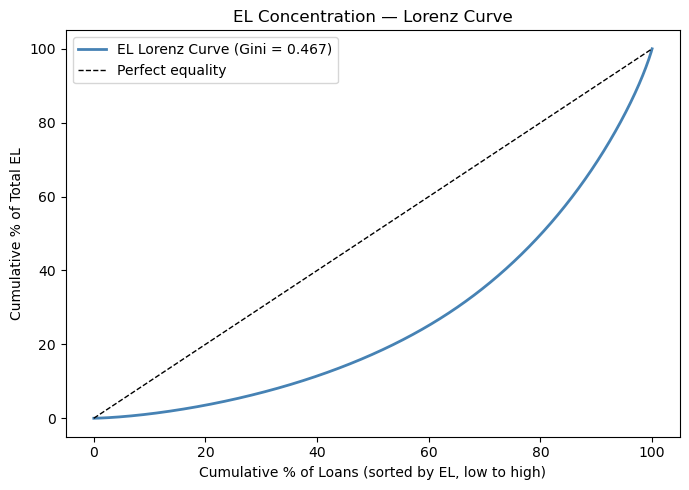

Gini coefficient of EL distribution : 0.4674
Top 20% riskiest borrowers account for 50.3% of total EL


In [14]:
el_sorted = df['el'].sort_values().values
n = len(el_sorted)
cum_loans = np.arange(1, n + 1) / n
cum_el    = el_sorted.cumsum() / el_sorted.sum()

# Gini coefficient
gini = 1 - 2 * np.trapz(cum_el, cum_loans)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(cum_loans * 100, cum_el * 100, color='steelblue', linewidth=2,
        label=f'EL Lorenz Curve (Gini = {gini:.3f})')
ax.plot([0, 100], [0, 100], 'k--', linewidth=1, label='Perfect equality')
ax.set_xlabel('Cumulative % of Loans (sorted by EL, low to high)')
ax.set_ylabel('Cumulative % of Total EL')
ax.set_title('EL Concentration — Lorenz Curve')
ax.legend()
plt.tight_layout()
plt.show()

# What % of EL is in the top 20% riskiest borrowers?
threshold_80 = np.percentile(df['el'], 80)
top_20_el_share = df.loc[df['el'] >= threshold_80, 'el'].sum() / df['el'].sum()
print(f'Gini coefficient of EL distribution : {gini:.4f}')
print(f'Top 20% riskiest borrowers account for {top_20_el_share:.1%} of total EL')

## **Cutoff Simulation**

In practice, the PD score is the primary lending decision variable. A cutoff $c$ means: approve the loan if $\text{PD} < c$, reject otherwise. Tightening the cutoff reduces default risk but also reduces approval rate (volume).

This simulation sweeps a range of PD cutoffs and records, for each:
- **Approval rate**: fraction of applicants approved
- **Portfolio EL ratio**: mean EL/funded_amnt on the approved book
- **Mean PD** on the approved book
- **Total EL avoided** vs. the no-cutoff baseline (approving everyone)

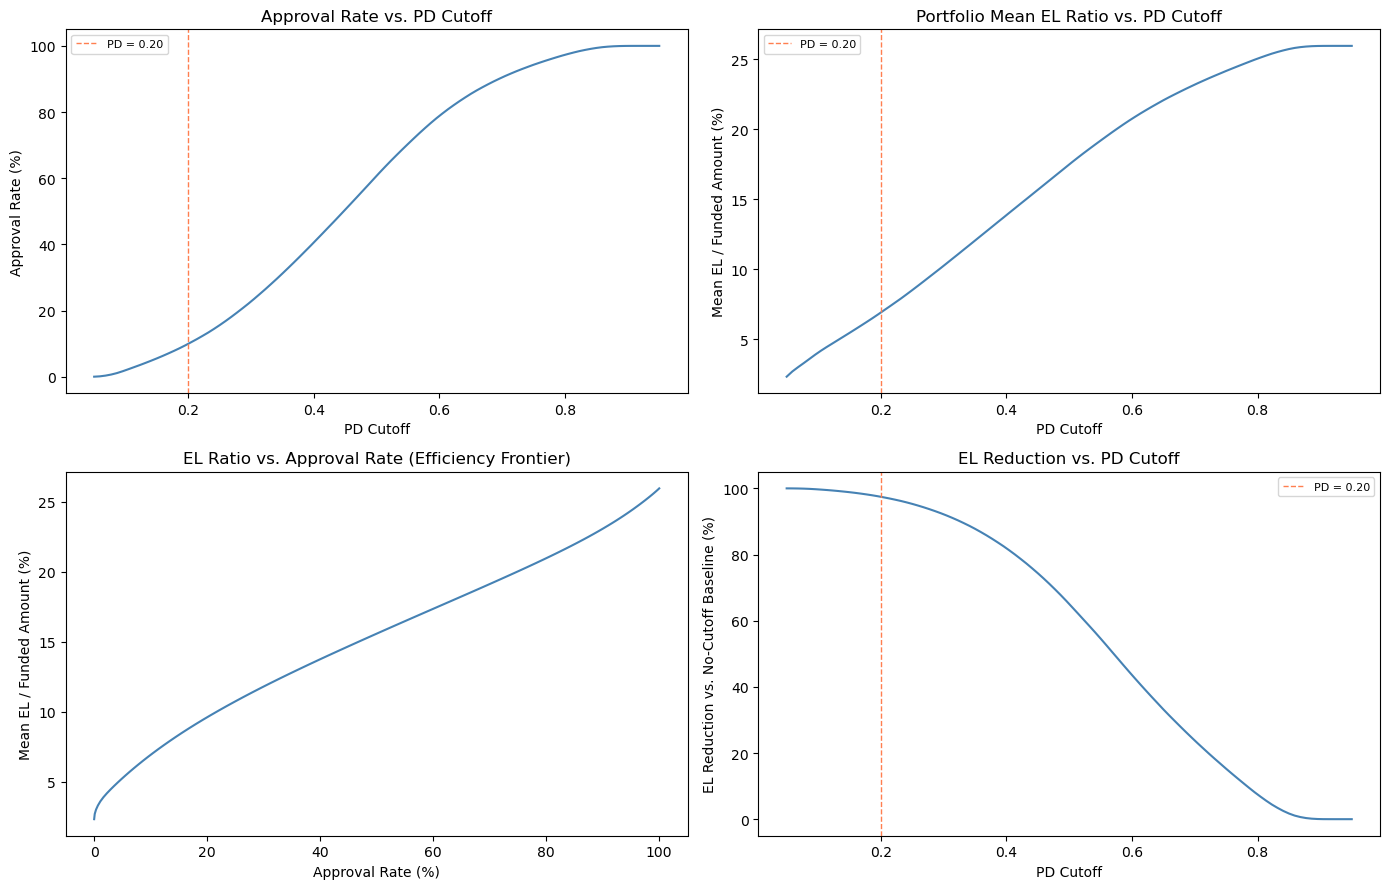

In [15]:
cutoffs = np.linspace(0.05, 0.95, 100)

results = []
baseline_el = df['el'].sum()

for c in cutoffs:
    approved = df[df['pd_score'] < c]
    if len(approved) == 0:
        continue
    results.append({
        'cutoff':        c,
        'approval_rate': len(approved) / len(df),
        'mean_pd':       approved['pd_score'].mean(),
        'mean_el_ratio': approved['el_ratio'].mean(),
        'total_el':      approved['el'].sum(),
        'el_reduction':  1 - approved['el'].sum() / baseline_el,
    })

sim = pd.DataFrame(results)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].plot(sim['cutoff'], sim['approval_rate'] * 100, color='steelblue')
axes[0, 0].set_title('Approval Rate vs. PD Cutoff')
axes[0, 0].set_xlabel('PD Cutoff')
axes[0, 0].set_ylabel('Approval Rate (%)')
axes[0, 0].axvline(0.20, color='coral', linestyle='--', linewidth=1, label='PD = 0.20')
axes[0, 0].legend(fontsize=8)

axes[0, 1].plot(sim['cutoff'], sim['mean_el_ratio'] * 100, color='steelblue')
axes[0, 1].set_title('Portfolio Mean EL Ratio vs. PD Cutoff')
axes[0, 1].set_xlabel('PD Cutoff')
axes[0, 1].set_ylabel('Mean EL / Funded Amount (%)')
axes[0, 1].axvline(0.20, color='coral', linestyle='--', linewidth=1, label='PD = 0.20')
axes[0, 1].legend(fontsize=8)

axes[1, 0].plot(sim['approval_rate'] * 100, sim['mean_el_ratio'] * 100, color='steelblue')
axes[1, 0].set_title('EL Ratio vs. Approval Rate (Efficiency Frontier)')
axes[1, 0].set_xlabel('Approval Rate (%)')
axes[1, 0].set_ylabel('Mean EL / Funded Amount (%)')

axes[1, 1].plot(sim['cutoff'], sim['el_reduction'] * 100, color='steelblue')
axes[1, 1].set_title('EL Reduction vs. PD Cutoff')
axes[1, 1].set_xlabel('PD Cutoff')
axes[1, 1].set_ylabel('EL Reduction vs. No-Cutoff Baseline (%)')
axes[1, 1].axvline(0.20, color='coral', linestyle='--', linewidth=1, label='PD = 0.20')
axes[1, 1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [16]:
# Print a reference table for a few representative cutoffs
ref_cutoffs = [0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]
ref = sim[sim['cutoff'].apply(lambda x: any(abs(x - c) < 0.005 for c in ref_cutoffs))].copy()
ref = ref.drop_duplicates(subset=['cutoff']).round(4)
display(ref.to_string(index=False))

' cutoff  approval_rate  mean_pd  mean_el_ratio           total_el  el_reduction\n 0.0955         0.0166   0.0789         0.0390    13,379,648.2701        0.9975\n 0.1045         0.0227   0.0845         0.0418    19,569,452.7696        0.9963\n 0.1500         0.0556   0.1101         0.0545    61,731,544.4752        0.9885\n 0.1955         0.0952   0.1365         0.0677   127,752,477.7453        0.9761\n 0.2045         0.1044   0.1421         0.0705   145,013,166.1858        0.9729\n 0.2500         0.1561   0.1706         0.0851   251,016,318.1142        0.9531\n 0.2955         0.2206   0.2007         0.1009   401,566,074.4559        0.9249\n 0.3045         0.2349   0.2067         0.1041   437,759,133.9379        0.9182\n 0.3955         0.3973   0.2659         0.1370   936,240,521.7623        0.8250\n 0.4045         0.4151   0.2716         0.1403 1,001,771,963.7274        0.8127\n 0.4955         0.5981   0.3263         0.1731 1,820,443,300.6238        0.6597\n 0.5045         0.6169   0.

The **efficiency frontier** (EL ratio vs. approval rate) is the most useful operational chart. Each point on the curve represents a different PD cutoff, moving left tightens the policy (fewer approvals, lower EL ratio) and moving right loosens it. The goal is to identify the point of diminishing returns: where tightening further reduces approval rate steeply without proportionally reducing EL.

## **Scenario Analysis — PD Stress Test**

A stress test applies a multiplicative shock to all PD scores to simulate a macro downturn. Under stress, PDs rise uniformly, which increases EL across the portfolio. This shows how sensitive total EL is to systematic credit deterioration.

Typical stress multipliers: 1.5× (mild), 2.0× (moderate), 3.0× (severe).

In [17]:
scenarios = {
    'Base':   1.0,
    'Mild':   1.5,
    'Moderate': 2.0,
    'Severe': 3.0,
}

scenario_results = []
for scenario, multiplier in scenarios.items():
    stressed_pd  = (df['pd_score'] * multiplier).clip(0, 1)
    stressed_el  = stressed_pd * df['lgd_hat'] * df['ead_hat']
    scenario_results.append({
        'Scenario':          scenario,
        'PD Multiplier':     multiplier,
        'Mean PD':           stressed_pd.mean(),
        'Total EL ($M)':     stressed_el.sum() / 1e6,
        'Mean EL Ratio (%)': (stressed_pd * df['lgd_hat'] * df['ead_ratio_hat']).mean() * 100,
        'EL Increase (%)':   (stressed_el.sum() / df['el'].sum() - 1) * 100,
    })

scenario_df = pd.DataFrame(scenario_results)
display(scenario_df.round(3))

,Scenario,PD Multiplier,Mean PD,Total EL ($M),Mean EL Ratio (%),EL Increase (%)
0,Base,1.0000,0.4470,"5,349.6290",25.9460,-0.0000
1,Mild,1.5000,0.6550,"7,752.3080",37.8510,44.9130
2,Moderate,2.0000,0.7920,"9,115.3080",45.2920,70.3910
3,Severe,3.0000,0.9090,"10,164.5310",51.3420,90.0040


## **Export**

Export the full loan-level results table for use in the dashboard or further analysis.

In [18]:
export_cols = [
    'funded_amnt', 'term', 'grade_label', 'int_rate', 'purpose',
    'issue_d_year', 'is_default',
    'pd_score', 'lgd_hat', 'ead_ratio_hat', 'ead_hat', 'el', 'el_ratio',
]

df[export_cols].to_parquet('el_results.parquet', index=False)
print(f'Exported el_results.parquet — {len(df):,} rows, {len(export_cols)} columns')

# Also export the grade-level summary as CSV for quick reference
grade_summary.to_csv('el_by_grade.csv', index=False)
print('Exported el_by_grade.csv')

Exported el_results.parquet — 1,345,310 rows, 13 columns
Exported el_by_grade.csv
